# Line Segmentation in Historical Document

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import pandas as pd

## Document Image Preprocessing

### Data Loading and Exploration

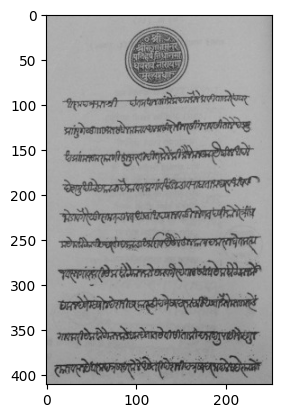

In [71]:
def load_document_image():
    img = cv2.imread('historical-doc.png')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

img = load_document_image()
plt.imshow(img)
plt.show()

Dimensions of the image:  (411, 251, 3)
Min pixel value:  28
Max pixel value:  190
Distribution of pixel values: 


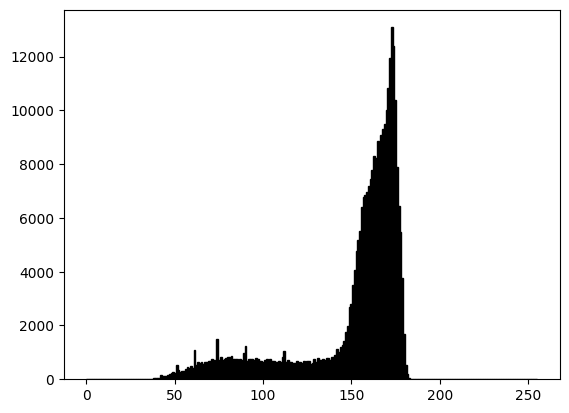

In [72]:
print("Dimensions of the image: ", img.shape)
print("Min pixel value: ", img.min())
print("Max pixel value: ", img.max())
print("Distribution of pixel values: ")
plt.hist(img.ravel(), bins=256, range=(0, 255), fc='k', ec='k')
plt.show()

### Image Preprocessing for Text Line Detection

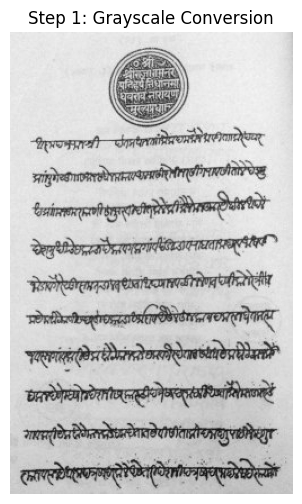

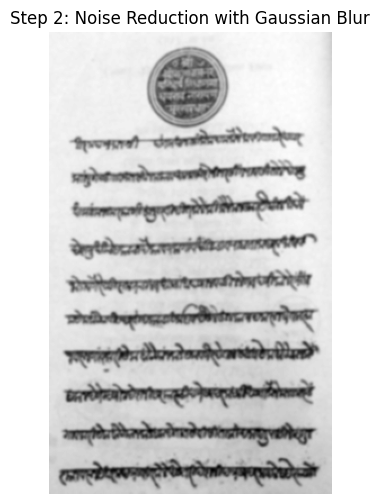

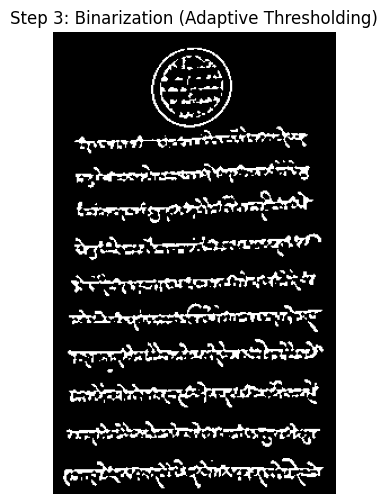

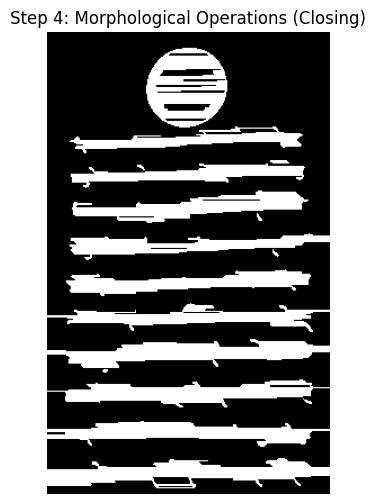

In [73]:
def preprocess_image(image):

    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    plt.figure(figsize=(10, 6))
    plt.imshow(grayscale, cmap='gray')
    plt.title("Step 1: Grayscale Conversion")
    plt.axis("off")
    plt.show()

    blurred = cv2.GaussianBlur(grayscale, (5, 5), 0)
    plt.figure(figsize=(10, 6))
    plt.imshow(blurred, cmap='gray')
    plt.title("Step 2: Noise Reduction with Gaussian Blur")
    plt.axis("off")
    plt.show()

    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)
    plt.figure(figsize=(10, 6))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 3: Binarization (Adaptive Thresholding)")
    plt.axis("off")
    plt.show()

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1))
    morphed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    plt.figure(figsize=(10, 6))
    plt.imshow(morphed, cmap='gray')
    plt.title("Step 4: Morphological Operations (Closing)")
    plt.axis("off")
    plt.show()

    return morphed

preprocessed_img = preprocess_image(img)


### Justification for Each Preprocessing Step

#### Grayscale Conversion
- The image was changed to grayscale to simplify it by focusing only on brightness levels. This makes it easier for further processing.

#### Gaussian Blurring
- Blurring was applied to minimize noise while keeping the text clear. This step helps make the image easier to work with.

#### Binary Thresholding
- The image was converted to a binary format to distinguish the text from the background, which is important for detecting text lines.
- Adaptive thresholding was used to manage different lighting conditions throughout the image.

#### Morphological Operations
- A rectangular kernel of size (5×5) was used for morphological closing. This step fills in small gaps within text lines, ensuring that broken or fragmented parts of the text are connected, which is essential for accurate line detection.

## Text Line Detection and Segmentation

###  Rectangular Bounding Box Detection

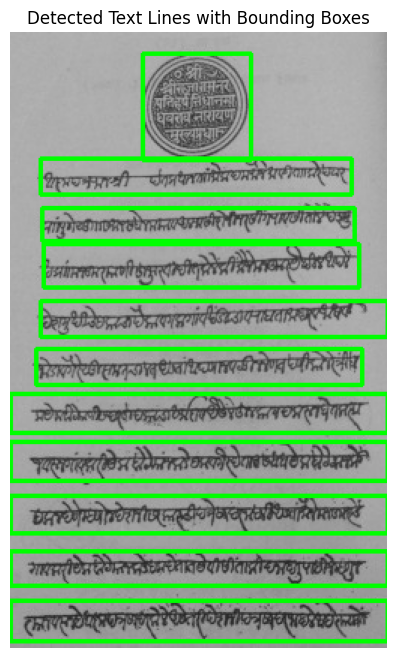

11 text lines detected and saved in 'detected_lines'.


In [74]:
def detect_lines_with_bboxes(image):

    output_dir = "detected_lines"
    os.makedirs(output_dir, exist_ok=True)

    # Preprocessing the image
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(grayscale, (5, 5), 0)
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)

    # Morphological operation to enhance text lines
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1)) 
    morphed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output_image = image.copy()
    line_count = 0

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        if w > 50 and h > 10:
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

            cropped_line = image[y:y + h, x:x + w]
            line_count += 1
            line_filename = os.path.join(output_dir, f"line_{line_count}.png")
            cv2.imwrite(line_filename, cropped_line)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title("Detected Text Lines with Bounding Boxes")
    plt.axis("off")
    plt.show()

    print(f"{line_count} text lines detected and saved in '{output_dir}'.")

    return output_image

output_image = detect_lines_with_bboxes(img)

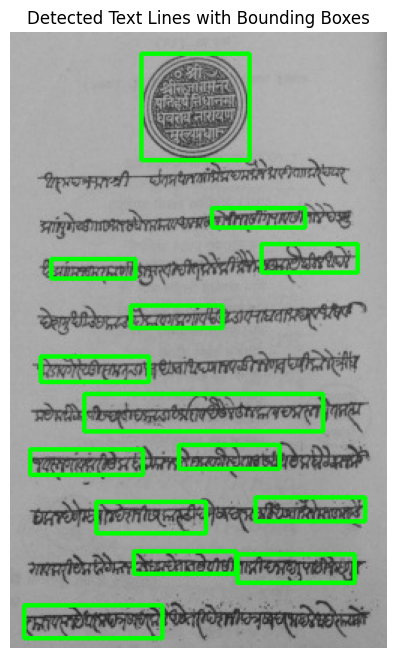

In [75]:
# without morphing
def detect_lines_with_bboxes(image):

    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(grayscale, (5, 5), 0)
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output_image = image.copy()
    line_count = 0

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        if w > 50 and h > 10:
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title("Detected Text Lines with Bounding Boxes")
    plt.axis("off")
    plt.show()

    return output_image

output_image = detect_lines_with_bboxes(img)

Without using morphological operations, the bounding boxes do not properly enclose the text lines. This happens because the text lines are broken or fragmented, preventing the bounding boxes from capturing the complete text line.

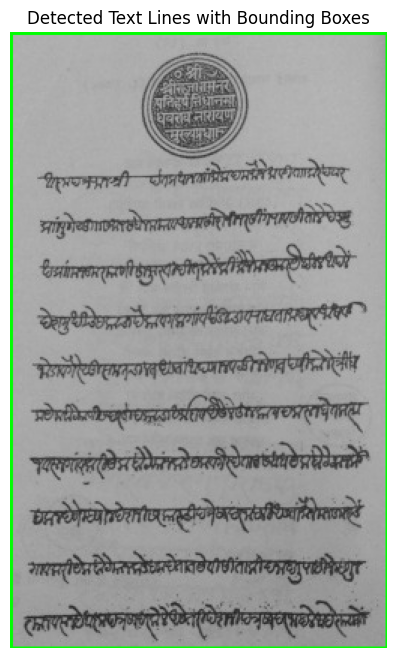

In [76]:
# without binarisation
def detect_lines_with_bboxes(image):

    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(grayscale, (5, 5), 0)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1)) 
    morphed = cv2.morphologyEx(blurred, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output_image = image.copy()

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        if w > 50 and h > 10:
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title("Detected Text Lines with Bounding Boxes")
    plt.axis("off")
    plt.show()

    return output_image

output_image = detect_lines_with_bboxes(img)

Without binarization, the bounding boxes are not detected at all because the text lines are not separated from the background. This makes it hard to accurately identify the text lines.

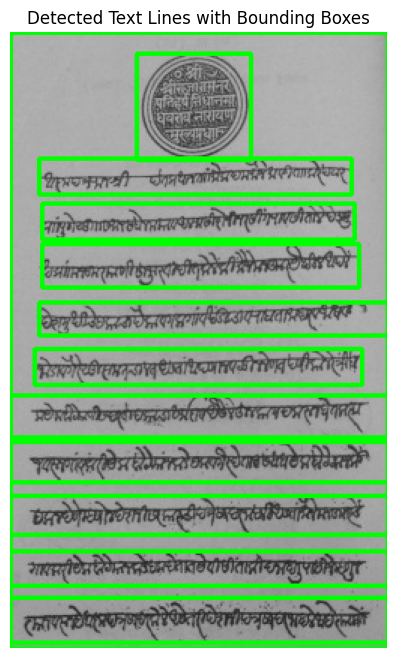

In [77]:
# without blurring
def detect_lines_with_bboxes(image):

    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    binary = cv2.adaptiveThreshold(grayscale, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1)) 
    morphed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        if w > 50 and h > 10:
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title("Detected Text Lines with Bounding Boxes")
    plt.axis("off")
    plt.show()

    return output_image

output_image = detect_lines_with_bboxes(img)

Without Guassian Blurring, we can see that the contours are not detected properly, they are overlapping and at the seal we can see 2 bounding boxes. This is might be due noise in the image.

The algorithm effectively detected and saved text lines by finding contours and using bounding boxes. It worked well for clear, well-separated lines. However, it might have difficulty with lines that are close together, overlapping text, or uneven shapes, which can result in merged or broken detections.

###  Line Segmentation within the Circular Region

Detected circle at (x=122, y=49) with radius r=35.


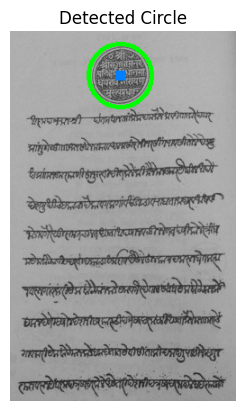

In [78]:
def detect_circle(image):
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(grayscale, (5, 5), 0)
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)
    
    circles = cv2.HoughCircles(
        binary, cv2.HOUGH_GRADIENT, dp=1.6, minDist=30, param1=30, param2=50, minRadius=30, maxRadius=40
    )
    
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")

        for (x, y, r) in circles:
            cv2.circle(image, (x, y), r, (0, 255, 0), 4)
            cv2.rectangle(image, (x - 5, y - 5), (x + 5, y + 5), (0, 128, 255), -1)
        return image, (x, y, r)
    return image, None

img = load_document_image()
output_image, circle_info = detect_circle(img)

if circle_info is not None:
    x, y, r = circle_info
    print(f"Detected circle at (x={x}, y={y}) with radius r={r}.")
    plt.imshow(output_image)
    plt.title('Detected Circle')
    plt.axis('off')
    plt.show()
else:
    print("No circle detected.")

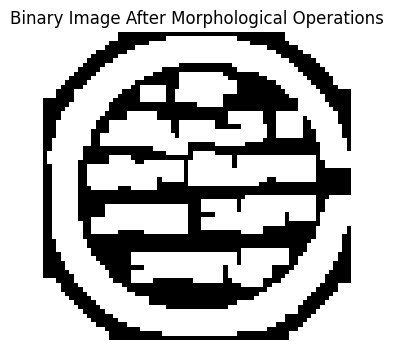

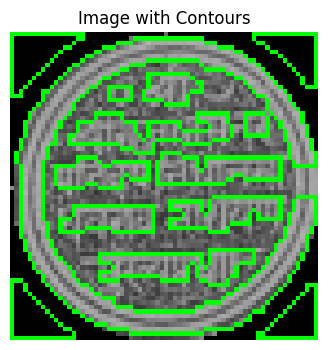

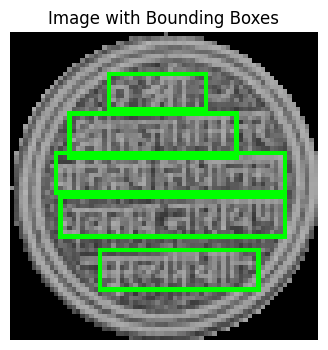

In [79]:
def detect_and_save_lines(image, circle_info, output_dir="detected_lines_circle"):
    if circle_info is None:
        return

    os.makedirs(output_dir, exist_ok=True)

    x, y, r = circle_info
    mask = np.zeros_like(image)
    cv2.circle(mask, (x, y), r, (255, 255, 255), -1)
    circular_region = cv2.bitwise_and(image, mask)

    circular_region = circular_region[y - r:y + r, x - r:x + r]


    if len(circular_region.shape) == 3:
        gray = cv2.cvtColor(circular_region, cv2.COLOR_RGB2GRAY)
    else:
        gray = circular_region
    
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        15, 10
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
    denoised = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    denoised = cv2.bitwise_not(denoised)

    plt.figure(figsize=(4, 4))
    plt.imshow(denoised, cmap='gray')
    plt.title('Binary Image After Morphological Operations')
    plt.axis('off')
    plt.show()

    contours, _ = cv2.findContours(denoised, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

    contour_image = cv2.cvtColor(circular_region, cv2.COLOR_GRAY2BGR) if len(circular_region.shape) == 2 else circular_region.copy()
    cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
    plt.title('Image with Contours')
    plt.axis('off')
    plt.show()

    bounding_boxes = []

    # Merging the closely spaced bounding boxes and filtering the proper bounding boxes was generated by chatgpt

    # Filter and process contours
    for contour in contours:
        # Get bounding rectangle for each contour
        x, y, w, h = cv2.boundingRect(contour)

        # Filter contours based on size and aspect ratio
        if w > 5 and h < 12:  # Adjust the thresholds as needed
            # Approximate the contour to a polygon
            epsilon = 0.02 * cv2.arcLength(contour, True)
            approx = cv2.approxPolyDP(contour, epsilon, True)

            # Get bounding box for the approximated polygon
            x, y, w, h = cv2.boundingRect(approx)

            # Save bounding box details for potential merging later
            bounding_boxes.append((x, y, w, h))

    # Sort bounding boxes by y-coordinate
    bounding_boxes = sorted(bounding_boxes, key=lambda x: x[1])

    # Merge closely spaced bounding boxes
    merged_boxes = []
    for i, box in enumerate(bounding_boxes):
        if i == 0:
            merged_boxes.append(box)
        else:
            prev_box = merged_boxes[-1]
            if abs(box[1] - prev_box[1]) < 5:
                merged_boxes[-1] = (
                    min(prev_box[0], box[0]),
                    prev_box[1],               
                    max(prev_box[0] + prev_box[2], box[0] + box[2]) - min(prev_box[0], box[0]),
                    max(prev_box[1] + prev_box[3], box[1] + box[3]) - prev_box[1] 
                )
            else:
                merged_boxes.append(box)

    line_number = 1
    for (x, y, w, h) in merged_boxes:
        cv2.rectangle(circular_region, (x, y), (x + w, y + h), (0, 255, 0), 1)
        cropped_line = circular_region[y:y + h, x:x + w]
        output_path = os.path.join(output_dir, f"circle_line_{line_number}.png")
        cv2.imwrite(output_path, cropped_line)
        line_number += 1

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(circular_region, cv2.COLOR_BGR2RGB))
    plt.title('Image with Bounding Boxes')
    plt.axis('off')
    plt.show()


img = load_document_image()
detect_and_save_lines(img, circle_info)


#### Challenges in Segmenting Lines Within the Circular Region
- The text within the circular region is curved, making precise detection and segmentation of individual lines difficult.
- Lines are positioned very close to one another, often resulting in overlapping or merged detections.
- Significant noise within the circular region hinders accurate contour detection and segmentation of lines.
- While some contours are identified, they fail to correctly separate into distinct text lines.

## Tighter Polygonal Boundary Detection

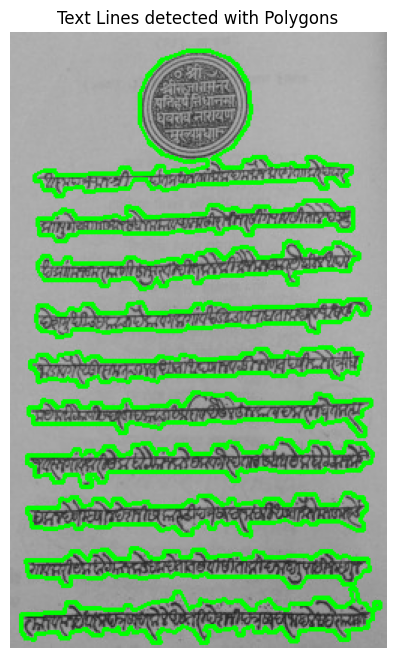

In [80]:
def detect_lines_with_polygons(image):
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(grayscale, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output_image = image.copy()

    for contour in contours:
        if cv2.contourArea(contour) < 100:
            continue
        epsilon = 0.002 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        cv2.drawContours(output_image, [approx], -1, (0, 255, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title("Text Lines detected with Polygons")
    plt.axis("off")
    plt.show()

    return output_image

img = load_document_image()
output_image = detect_lines_with_polygons(img)

- Polygonal boundaries are better at detecting text lines accurately, especially when the text is curved or tilted, making them ideal for complex documents.

- Rectangular boxes work well for clean, structured documents, while polygonal boundaries are better for irregular layouts.

- This method ensures every text line is captured without missing or merging any part of it.

